# Seasonal Agriculture Performance Analysis

### Major Data Analytics Project

**Domain:** Agriculture

## Project Goal

The goal of this project is to analyze agricultural performance across different seasons and identify meaningful patterns, trends, relationships, and variations in agricultural activities.

The analysis focuses on environmental conditions, farming practices, resource usage, crop production, and economic performance to understand how agricultural outcomes differ across seasons.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, crop characteristics, and economic factors. As a result, agricultural performance may differ from one season to another.

Raw agricultural data does not clearly explain how these factors vary across seasons or how they influence agricultural outcomes.

Therefore, this project aims to analyze the available agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the data.

## 2. Project Objectives

The main objectives of this project are:

- Understand the structure and characteristics of the agricultural dataset.
- Clean and prepare the data for analysis.
- Analyze agricultural performance across different seasons.
- Compare crop yield and production across seasons.
- Examine variations in environmental conditions between seasons.
- Analyze differences in resource usage across seasons.
- Compare revenue, cost, and profit across seasons.
- Investigate relationships between environmental conditions and agricultural performance.
- Identify significant patterns, variations, and unusual observations.
- Apply appropriate statistical and visualization techniques.
- Develop evidence-based findings and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, crops, locations, environmental conditions, farming practices, resource usage, production, and economic performance.

**Dataset File:** `seasonal_agriculture_performance_dataset.xlsx`

The dataset is used to analyze seasonal variations and identify patterns in agricultural performance.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.xlsx to seasonal_agriculture_performance_dataset (1).xlsx


In [76]:
# Load the dataset

file_path = "/content/seasonal_agriculture_performance_dataset.xlsx"
df = pd.read_excel(file_path)


## 4. Initial Data Understanding

In [77]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [78]:
# First 5 rows

df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [79]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [80]:
# Column names

df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [81]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [82]:
# Statistical summary

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [83]:
# Check for missing values

df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [84]:
# Check for duplicate records

df.duplicated().sum()

np.int64(0)

In [85]:
# Unique values in important categorical columns

print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].unique())

Seasons: ['Kharif' 'Rabi' 'Zaid']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
States: ['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']


#5. Data Cleaning

In [86]:
# Missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8


In [87]:
# Create a copy for data cleaning

df_clean = df.copy()

In [88]:
# Handle missing values

df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(
    df_clean['Rainfall_mm'].median()
)

df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(
    df_clean['Soil_Moisture_pct'].median()
)

df_clean = df_clean.dropna(subset=['Yield_Tonnes_Ha'])

In [89]:
# Verify missing values after cleaning

df_clean.isnull().sum().sum()

np.int64(0)

In [90]:
df_clean.shape

(3968, 28)

#6.Exploratory Data Analysis

In [91]:
# Distribution of agricultural records across seasons

df_clean['Season'].value_counts()

,count
Season,
Kharif,1772
Rabi,1607
Zaid,589


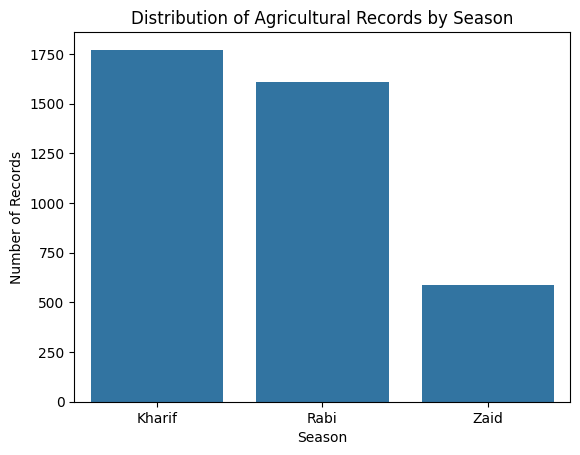

In [92]:
# Visualize season distribution

sns.countplot(data=df_clean, x='Season')

plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.show()

In [93]:
# Distribution of agricultural records across crops

df_clean['Crop'].value_counts()

,count
Crop,
Rice,682
Wheat,612
Maize,547
Cotton,504
Pulses,494
Groundnut,419
Chilli,407
Sugarcane,303


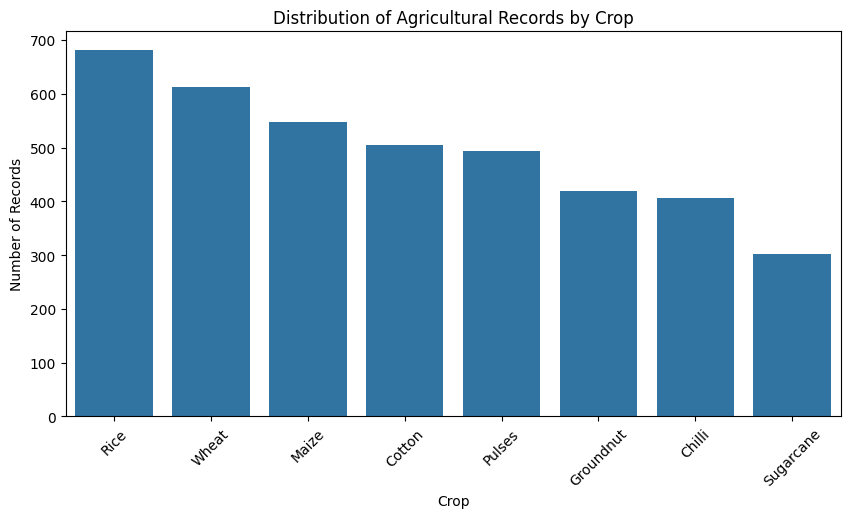

In [94]:
# Visualize crop distribution

plt.figure(figsize=(10, 5))

sns.countplot(data=df_clean, x='Crop', order=df_clean['Crop'].value_counts().index)

plt.title('Distribution of Agricultural Records by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

In [95]:
# Distribution of agricultural records across states

df_clean['State'].value_counts()

,count
State,
Andhra Pradesh,525
Telangana,511
Maharashtra,510
Madhya Pradesh,491
Punjab,484
Karnataka,483
Gujarat,483
Tamil Nadu,481


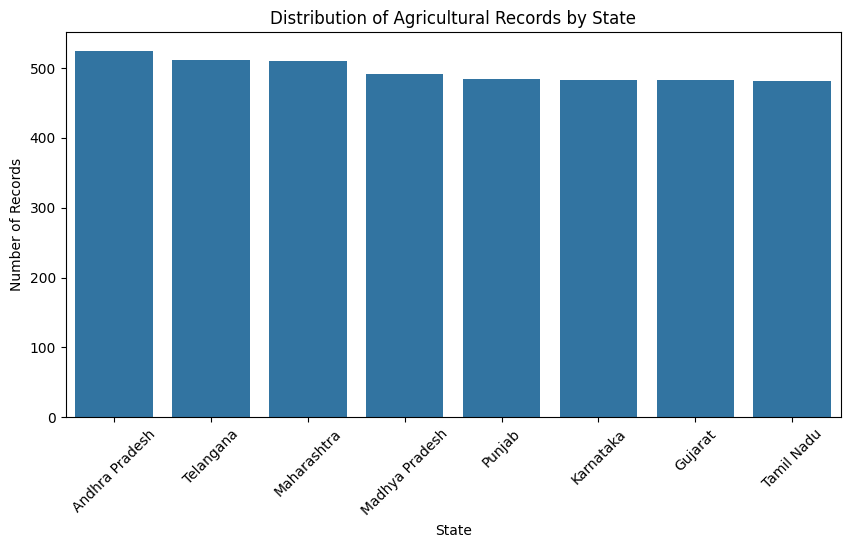

In [96]:
# Visualize state-wise distribution

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_clean,
    x='State',
    order=df_clean['State'].value_counts().index
)

plt.title('Distribution of Agricultural Records by State')
plt.xlabel('State')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

## 7. Seasonal Agricultural Performance Analysis

In [97]:
# Average crop yield across seasons

df_clean.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


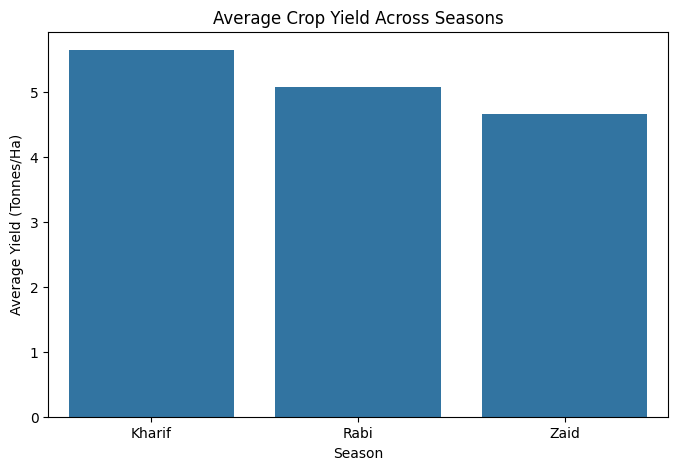

In [98]:
# Average yield across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    errorbar=None
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

In [99]:
# Average production across seasons

df_clean.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

,Production_Tonnes
Season,
Kharif,46.440830
Rabi,41.337953
Zaid,39.146146


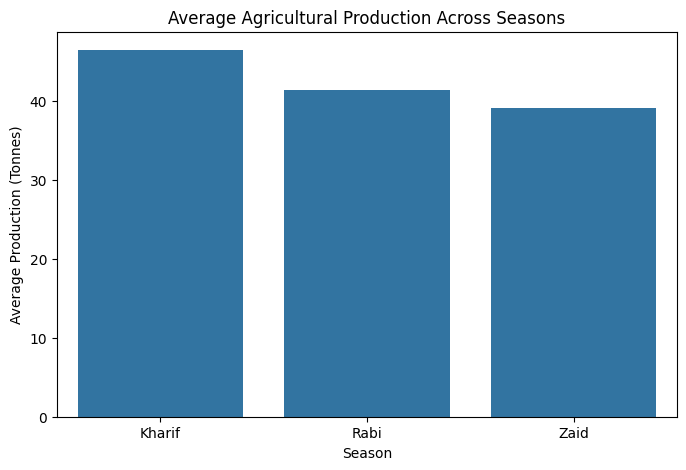

In [100]:
# Average production across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Production_Tonnes',
    errorbar=None
)

plt.title('Average Agricultural Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.show()

In [101]:
# Average revenue across seasons

df_clean.groupby('Season')['Revenue_INR'].mean().sort_values(ascending=False)

,Revenue_INR
Season,
Kharif,711441.277652
Rabi,601825.545737
Zaid,516662.120543


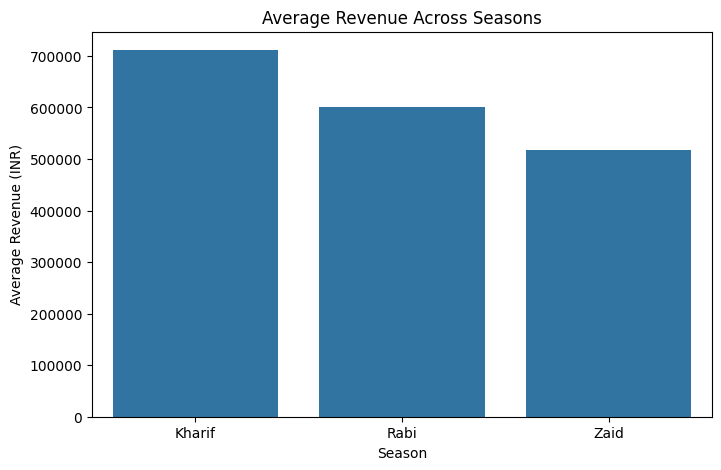

In [102]:
# Average revenue across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Revenue_INR',
    errorbar=None
)

plt.title('Average Revenue Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')
plt.show()

In [103]:
# Average profit across seasons

df_clean.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
Season,
Kharif,179367.124718
Rabi,88197.251400
Zaid,-26592.397284


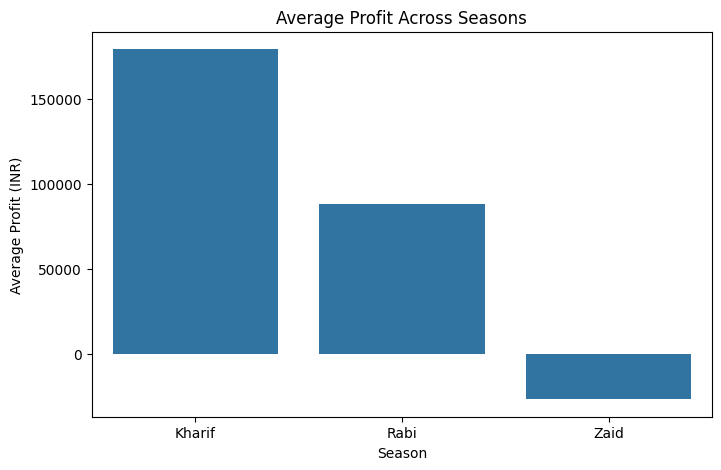

In [104]:
# Average profit across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    errorbar=None
)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

In [105]:
# Seasonal performance summary

seasonal_performance = df_clean.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

seasonal_performance

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,5.64,46.44,711441.28,532074.15,179367.12
Rabi,5.08,41.34,601825.55,513628.29,88197.25
Zaid,4.67,39.15,516662.12,543254.52,-26592.40


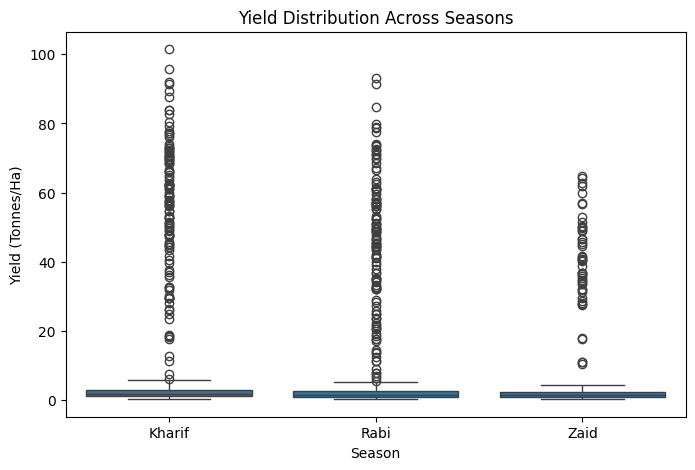

In [106]:
# Yield distribution across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [107]:
# Profit margin by season

seasonal_margin = df_clean.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
})

seasonal_margin['Profit_Margin_%'] = (
    seasonal_margin['Profit_INR'] /
    seasonal_margin['Revenue_INR'] * 100
).round(2)

seasonal_margin

,Revenue_INR,Profit_INR,Profit_Margin_%
Season,,,
Kharif,711441.277652,179367.124718,25.21
Rabi,601825.545737,88197.251400,14.65
Zaid,516662.120543,-26592.397284,-5.15


In [108]:
df_clean.groupby('Season')['Water_Used_m3'].mean().sort_values(ascending=False)

,Water_Used_m3
Season,
Zaid,6423.076401
Kharif,6094.046275
Rabi,5837.238955


In [109]:
# Average water efficiency across seasons

df_clean.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.906584
Rabi,5.178462
Zaid,4.440922


In [110]:
# Irrigation method distribution across seasons

irrigation_season = pd.crosstab(
    df_clean['Season'],
    df_clean['Irrigation_Method'],
    normalize='index'
).round(3) * 100

irrigation_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.9,33.1,26.0,18.1
Rabi,22.5,32.4,27.1,18.0
Zaid,23.8,32.3,23.8,20.2


In [111]:
# Average fertilizer usage across seasons

df_clean.groupby('Season')['Fertilizer_kg_ha'].mean().sort_values(ascending=False)

,Fertilizer_kg_ha
Season,
Kharif,187.041027
Rabi,185.282016
Zaid,184.233447


In [112]:
# Average disease and pest risk across seasons

df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

,Disease_Pest_Risk_pct
Season,
Kharif,54.465858
Rabi,40.519788
Zaid,38.221392


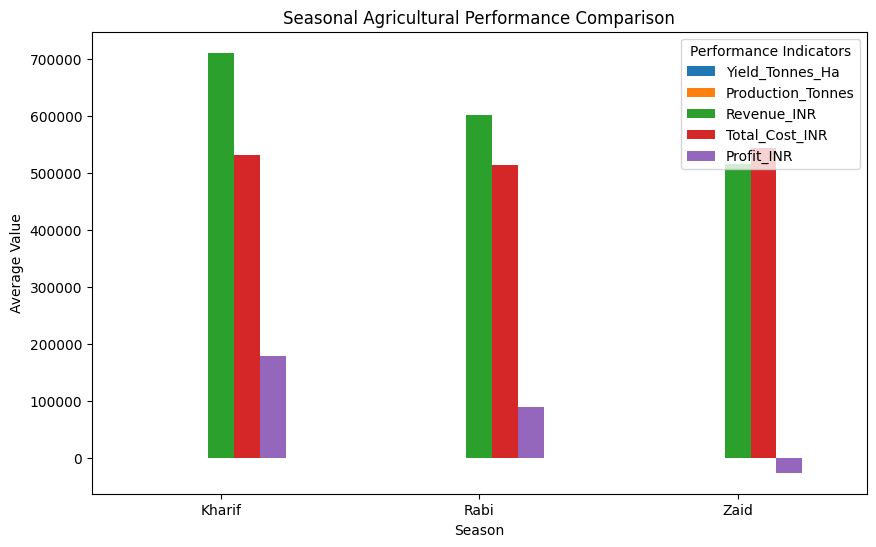

In [113]:
# Seasonal performance comparison

seasonal_performance[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR',
                      'Total_Cost_INR', 'Profit_INR']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Seasonal Agricultural Performance Comparison')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Performance Indicators')
plt.show()

## 8. Environmental Analysis

In [114]:
# Average environmental conditions across seasons

environmental_factors = df_clean.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean'
}).round(2)

environmental_factors

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,848.69,28.45,71.84,6.79
Rabi,437.93,23.50,57.92,7.59
Zaid,304.25,31.05,51.99,8.18


In [115]:
# Average soil conditions across seasons

soil_conditions = df_clean.groupby('Season').agg({
    'Soil_pH': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

soil_conditions

,Soil_pH,Soil_Moisture_pct
Season,,
Kharif,6.73,31.15
Rabi,6.67,24.09
Zaid,6.69,19.27


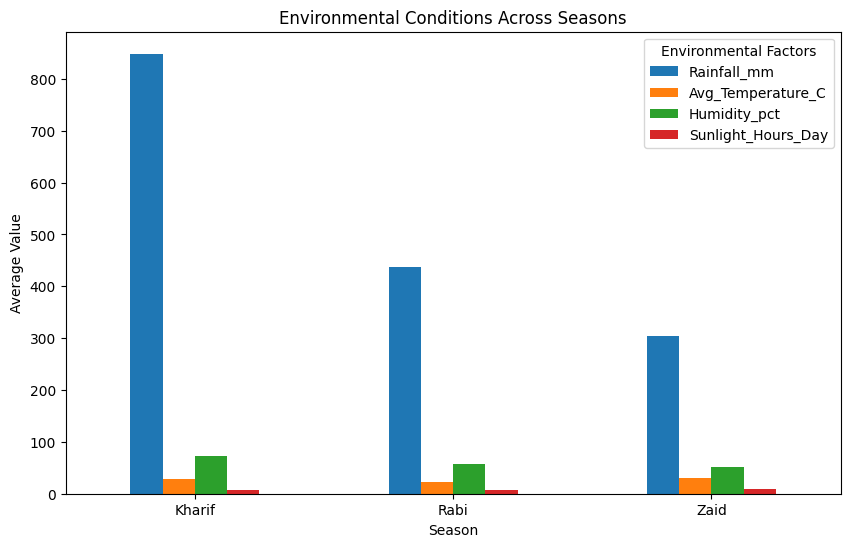

In [116]:
# Environmental conditions across seasons

environmental_factors.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Environmental Conditions Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Environmental Factors')
plt.show()

In [117]:
# Correlation between environmental factors and yield

environmental_yield_corr = df_clean[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(ascending=False)

environmental_yield_corr.round(2)

,Yield_Tonnes_Ha
Rainfall_mm,0.03
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01
Sunlight_Hours_Day,-0.02
Soil_pH,-0.02


### Key Environmental Findings

- Environmental conditions vary across the Kharif, Rabi, and Zaid seasons.
- Rainfall, temperature, humidity, and sunlight show noticeable seasonal differences.
- Soil pH and soil moisture also vary across seasons, affecting growing conditions.
- The correlation analysis indicates the strength and direction of relationships between environmental factors and crop yield.
- These environmental patterns help explain differences in agricultural performance across seasons.

## 9. Resource Usage Analysis

In [118]:
# Water usage and efficiency across seasons

water_analysis = df_clean.groupby('Season').agg({
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

water_analysis

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6094.05,5.91
Rabi,5837.24,5.18
Zaid,6423.08,4.44


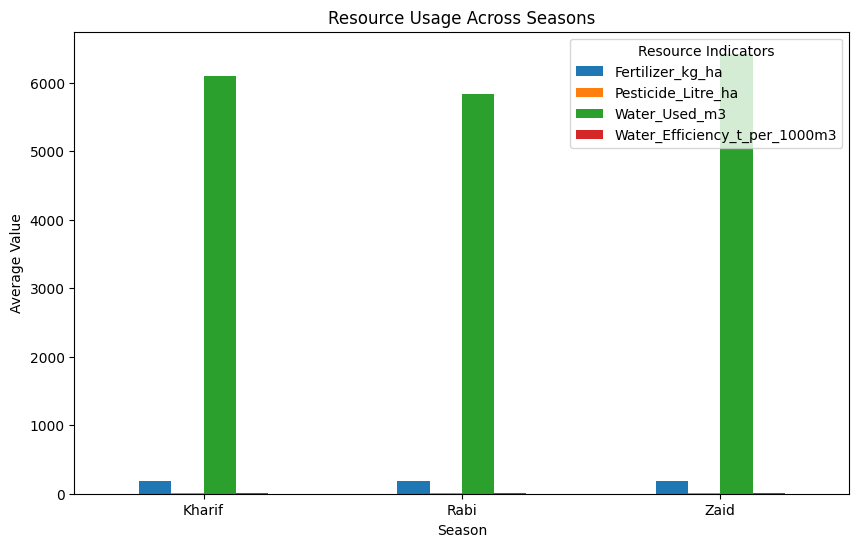

In [119]:
# Resource usage comparison across seasons

resource_comparison = df_clean.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
})

resource_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Resource Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='Resource Indicators')
plt.show()

### Key Resource Usage Findings

- Resource consumption varies across the Kharif, Rabi, and Zaid seasons.
- Fertilizer and pesticide usage show seasonal differences in agricultural practices.
- Zaid season requires higher water usage while showing lower water-use efficiency.
- Kharif demonstrates better water-use efficiency compared with the other seasons.
- These findings highlight the importance of improving resource efficiency, particularly during seasons with higher resource consumption.

## 10. Economic Performance Analysis

In [120]:
# Average economic indicators across seasons

economic_summary = df_clean.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean'
}).round(2)

economic_summary

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR
Season,,,
Kharif,44846.63,532074.15,711441.28
Rabi,44770.59,513628.29,601825.55
Zaid,43957.76,543254.52,516662.12


In [121]:
# Average profit and profit margin across seasons

profit_analysis = df_clean.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
})

profit_analysis['Profit_Margin_%'] = (
    profit_analysis['Profit_INR'] /
    profit_analysis['Revenue_INR'] * 100
).round(2)

profit_analysis

,Revenue_INR,Profit_INR,Profit_Margin_%
Season,,,
Kharif,711441.277652,179367.124718,25.21
Rabi,601825.545737,88197.251400,14.65
Zaid,516662.120543,-26592.397284,-5.15


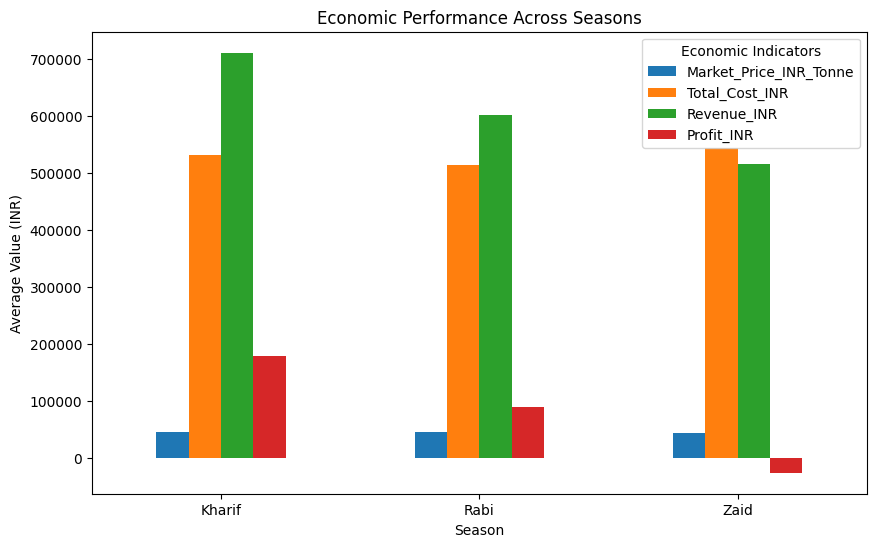

In [122]:
# Economic performance across seasons

economic_comparison = df_clean.groupby('Season').agg({
    'Market_Price_INR_Tonne': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
})

economic_comparison.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Economic Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value (INR)')
plt.xticks(rotation=0)
plt.legend(title='Economic Indicators')
plt.show()

### Key Economic Findings

- Economic performance varies significantly across the three agricultural seasons.
- Kharif shows the strongest overall profitability and the highest average profit margin.
- Rabi demonstrates moderate economic performance with positive profitability.
- Zaid records the lowest average revenue and negative average profit margin.
- These findings indicate that seasonal conditions have an important association with the economic outcomes of agricultural activities.

## 11. Relationship & Correlation Analysis

In [123]:
# Correlation matrix of key numerical variables

correlation_data = df_clean[[
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]]

correlation_matrix = correlation_data.corr().round(2)

correlation_matrix

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Rainfall_mm,1.00,0.20,0.52,-0.36,0.02,0.51,0.03,0.00,0.03,0.00,0.06,0.00,0.01,0.10,0.11
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.03,0.08,0.01,0.01,0.01,0.02,0.01,0.00,0.04,0.02,0.01
Humidity_pct,0.52,0.14,1.00,-0.30,0.03,0.45,0.03,-0.00,0.01,-0.00,0.03,0.00,0.00,0.06,0.06
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,-0.01,-0.02,-0.02,-0.00,-0.02,-0.00,-0.00,-0.05,-0.06
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,-0.01,-0.01,-0.02,-0.03,-0.01,0.02,0.00,-0.01,-0.01
Soil_Moisture_pct,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,-0.02,0.01,0.00,0.03,0.02,0.00,0.08,0.09
Fertilizer_kg_ha,0.03,0.01,0.03,-0.01,-0.01,0.01,1.00,-0.00,0.00,0.00,0.01,-0.00,0.15,0.00,-0.07
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.01,-0.02,-0.00,1.00,-0.01,0.00,-0.01,0.01,0.04,-0.00,-0.03
Yield_Tonnes_Ha,0.03,0.01,0.01,-0.02,-0.02,0.01,0.00,-0.01,1.00,0.39,0.92,-0.38,0.03,0.43,0.49
Water_Used_m3,0.00,0.02,-0.00,-0.00,-0.03,0.00,0.00,0.00,0.39,1.00,0.22,-0.34,0.57,0.43,0.19


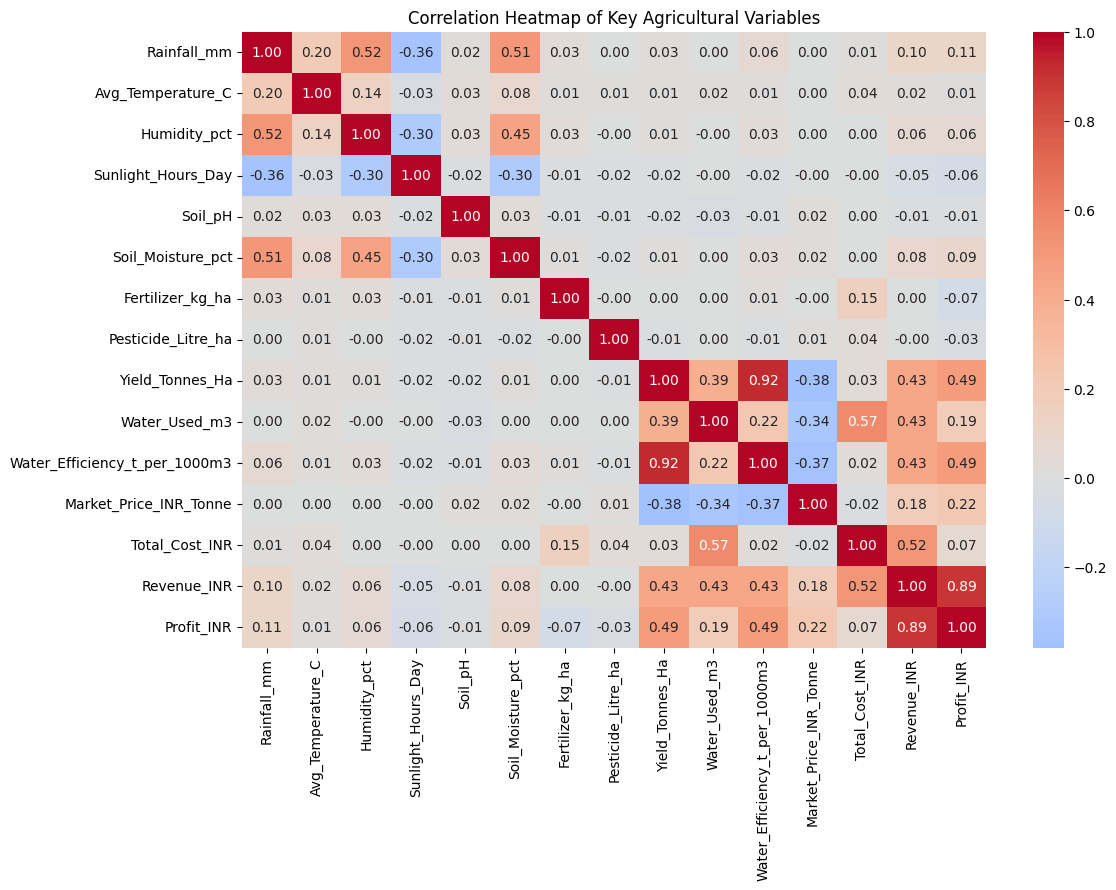

In [124]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Key Agricultural Variables')
plt.show()

In [125]:
# Variables most strongly correlated with yield

yield_correlations = (
    correlation_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(key=abs, ascending=False)
)

yield_correlations

,Yield_Tonnes_Ha
Water_Efficiency_t_per_1000m3,0.92
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Market_Price_INR_Tonne,-0.38
Rainfall_mm,0.03
Total_Cost_INR,0.03
Sunlight_Hours_Day,-0.02
Soil_pH,-0.02
Avg_Temperature_C,0.01


### Key Relationship Findings

- Correlation analysis helps identify the strength and direction of relationships among agricultural variables.
- Environmental and resource-related factors show varying degrees of association with crop yield.
- Yield is positively associated with water-use efficiency, while its relationship with other factors varies in strength.
- Economic indicators such as revenue, cost, and profit show strong relationships with each other.
- Correlation indicates association between variables but does not establish a causal relationship.

## 12. Regional Analysis

In [126]:
# Average crop yield across states

state_yield = (
    df_clean.groupby('State')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

state_yield

,Yield_Tonnes_Ha
State,
Punjab,6.12
Karnataka,5.73
Gujarat,5.70
Telangana,5.08
Maharashtra,5.03
Madhya Pradesh,5.03
Tamil Nadu,4.90
Andhra Pradesh,4.65


In [127]:
# Average profit across states

state_profit = (
    df_clean.groupby('State')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

state_profit

,Profit_INR
State,
Maharashtra,136874.14
Punjab,136025.64
Gujarat,120050.96
Tamil Nadu,119117.82
Karnataka,118495.57
Telangana,108282.06
Madhya Pradesh,89479.77
Andhra Pradesh,69497.23


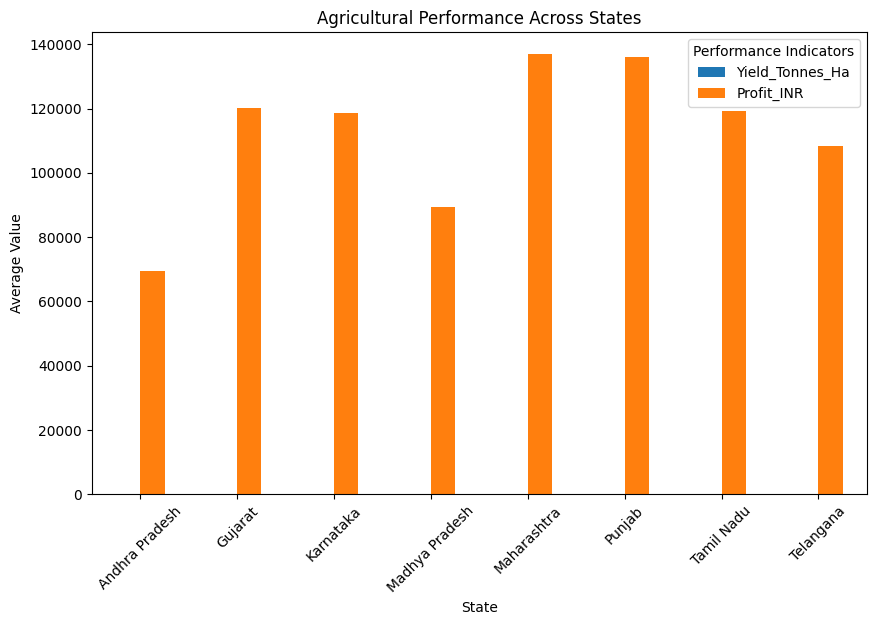

In [128]:
# State-wise yield and profit comparison

state_performance = df_clean.groupby('State').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean'
}).round(2)

state_performance.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Agricultural Performance Across States')
plt.xlabel('State')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Performance Indicators')
plt.show()

### Key Regional Findings

- Agricultural performance varies across different states.
- Average crop yield differs between regions, indicating variations in regional agricultural performance.
- Profitability also varies across states, highlighting differences in economic outcomes.
- The state-wise comparison helps identify stronger-performing and lower-performing regions.
- Regional differences can support targeted agricultural planning and resource allocation.

## 13. Crop-wise Analysis

In [129]:
# Average crop yield

crop_yield = (
    df_clean.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

crop_yield

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.94
Maize,2.72
Rice,2.44
Wheat,2.11
Chilli,1.54
Groundnut,1.32
Cotton,1.23
Pulses,0.92


In [130]:
# Average profit by crop

crop_profit = (
    df_clean.groupby('Crop')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

crop_profit


,Profit_INR
Crop,
Sugarcane,817245.40
Chilli,753377.50
Cotton,124969.85
Groundnut,44604.38
Pulses,-3987.21
Maize,-82749.43
Rice,-101405.00
Wheat,-123567.97


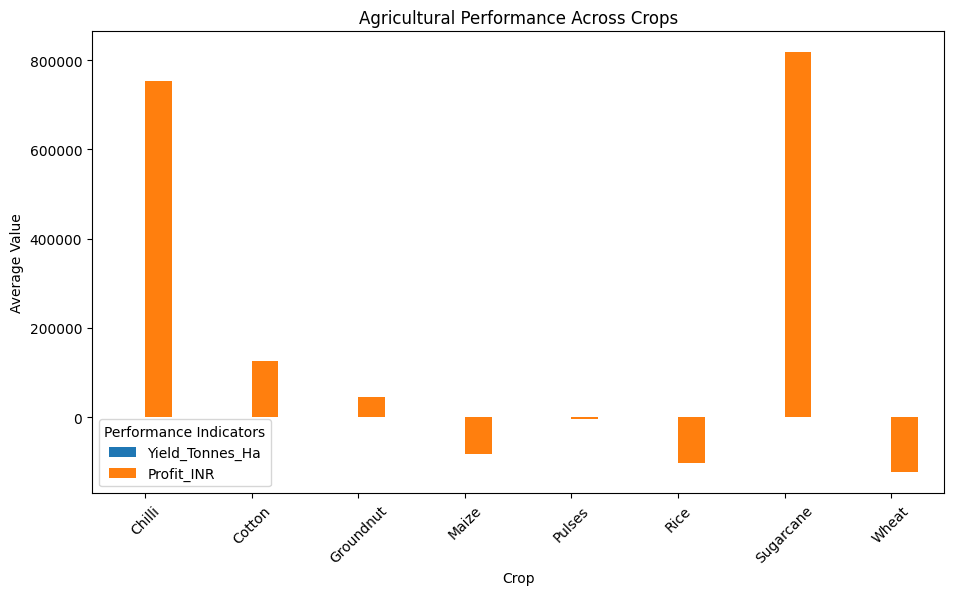

In [131]:
# Crop-wise yield and profit comparison

crop_performance = df_clean.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Profit_INR': 'mean'
}).round(2)

crop_performance.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Agricultural Performance Across Crops')
plt.xlabel('Crop')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.legend(title='Performance Indicators')
plt.show()

### Key Crop-wise Findings

- Agricultural performance varies across different crops.
- Average yield differs between crops, indicating variations in production performance.
- Profitability also varies across crops, reflecting differences in economic outcomes.
- The crop-wise comparison helps identify high-performing and lower-performing crops.
- These findings can support better crop selection and agricultural planning.

## 14. Statistical Analysis

In [132]:
# Descriptive statistics for key agricultural performance variables

statistical_summary = df_clean[[
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR',
    'Water_Used_m3'
]].describe().round(2)

statistical_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3
count,3968.00,3968.00,3968.00,3968.00,3968.00,3968.00
mean,5.27,43.29,638135.48,526263.35,111872.13,6038.88
std,13.36,127.07,637342.64,294195.53,545742.68,5567.51
min,0.30,0.15,6107.00,26826.00,-1019223.00,128.00
25%,1.05,5.04,209122.25,274801.75,-149267.25,2263.00
50%,1.74,11.83,456830.50,519313.00,3419.00,4433.50
75%,2.84,24.38,834879.75,761818.75,216187.75,7828.25
max,101.44,1424.40,5080900.00,1349990.00,4345421.00,40902.00


In [133]:
# Coefficient of Variation by season

cv_analysis = df_clean.groupby('Season').agg({
    'Yield_Tonnes_Ha': ['mean', 'std'],
    'Profit_INR': ['mean', 'std']
})

cv_analysis['Yield_CV_%'] = (
    cv_analysis[('Yield_Tonnes_Ha', 'std')] /
    cv_analysis[('Yield_Tonnes_Ha', 'mean')] * 100
)

cv_analysis['Profit_CV_%'] = (
    cv_analysis[('Profit_INR', 'std')] /
    cv_analysis[('Profit_INR', 'mean')].abs() * 100
)

cv_analysis[['Yield_CV_%', 'Profit_CV_%']].round(2)

,Yield_CV_%,Profit_CV_%
,,
Season,,
Kharif,255.48,341.55
Rabi,252.44,556.06
Zaid,242.56,1628.68


In [134]:
from scipy.stats import f_oneway

# One-way ANOVA: Yield across seasons

season_groups_yield = [
    group['Yield_Tonnes_Ha'].values
    for _, group in df_clean.groupby('Season')
]

yield_anova = f_oneway(*season_groups_yield)

yield_anova

F_onewayResult(statistic=np.float64(1.4579589466621523), pvalue=np.float64(0.23283549440109827))

In [135]:
# One-way ANOVA: Profit across seasons

season_groups_profit = [
    group['Profit_INR'].values
    for _, group in df_clean.groupby('Season')
]

profit_anova = f_oneway(*season_groups_profit)

profit_anova

F_onewayResult(statistic=np.float64(34.598068308766116), pvalue=np.float64(1.270155313392683e-15))

In [136]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD test for seasonal yield differences

tukey_yield = pairwise_tukeyhsd(
    endog=df_clean['Yield_Tonnes_Ha'],
    groups=df_clean['Season'],
    alpha=0.05
)

print(tukey_yield)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Kharif   Rabi  -0.5635 0.4388 -1.6425 0.5155  False
Kharif   Zaid   -0.978 0.2727 -2.4678 0.5118  False
  Rabi   Zaid  -0.4146 0.7957 -1.9233 1.0942  False
---------------------------------------------------


In [137]:
from scipy.stats import pearsonr

factors = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3'
]

correlation_results = []

for factor in factors:
    r, p = pearsonr(
        df_clean[factor],
        df_clean['Yield_Tonnes_Ha']
    )

    correlation_results.append({
        'Variable': factor,
        'Correlation_r': round(r, 3),
        'P_Value': round(p, 4)
    })

correlation_results = pd.DataFrame(correlation_results)
correlation_results

,Variable,Correlation_r,P_Value
0,Rainfall_mm,0.031,0.0544
1,Avg_Temperature_C,0.009,0.5560
2,Humidity_pct,0.011,0.4776
3,Sunlight_Hours_Day,-0.015,0.3333
4,Soil_Moisture_pct,0.010,0.5240
5,Fertilizer_kg_ha,0.001,0.9718
6,Pesticide_Litre_ha,-0.008,0.6300
7,Water_Used_m3,0.389,0.0000


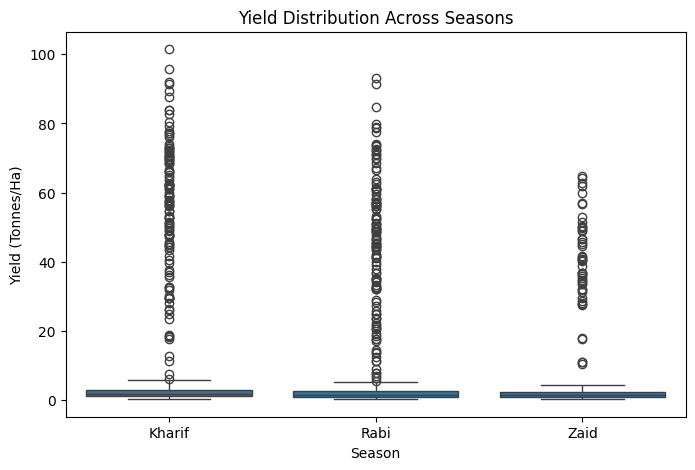

In [138]:
# Yield distribution by season for statistical comparison

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

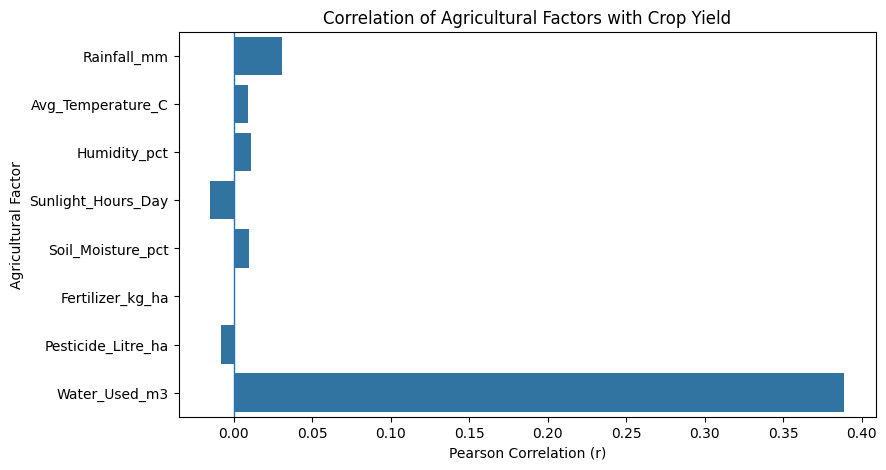

In [139]:
# Visualize correlations between key factors and yield

plt.figure(figsize=(9, 5))

sns.barplot(
    data=correlation_results,
    x='Correlation_r',
    y='Variable'
)

plt.title('Correlation of Agricultural Factors with Crop Yield')
plt.xlabel('Pearson Correlation (r)')
plt.ylabel('Agricultural Factor')
plt.axvline(0, linewidth=1)
plt.show()

### Key Statistical Findings

- Descriptive statistics summarize the central tendency and variability of key agricultural performance indicators.
- The coefficient of variation helps evaluate the consistency of yield and profit across seasons.
- One-way ANOVA tests whether differences in seasonal yield and profit are statistically significant.
- The Tukey HSD test identifies the specific seasonal pairs with significant yield differences.
- Pearson correlation measures the strength and direction of relationships between environmental and resource factors and crop yield.
- Statistical results should be interpreted using the p-value, with a significance level of 0.05.

## 15. Key Findings

### 15.1 Seasonal Performance Findings

- Kharif recorded the highest average crop yield, production, revenue, and profit among the three seasons.
- Rabi showed moderate agricultural and economic performance.
- Zaid recorded the lowest average yield, production, and revenue.
- Zaid also recorded a negative average profit margin, indicating weaker economic performance.
- Kharif demonstrated the highest water-use efficiency, while Zaid showed the lowest.

### 15.2 Environmental & Resource Findings

- Environmental conditions such as rainfall, temperature, humidity, and sunlight vary across seasons.
- Soil pH and soil moisture also show seasonal variation.
- Zaid recorded the highest average water usage among the seasons.
- Zaid had lower water-use efficiency despite higher water consumption.
- Fertilizer and pesticide usage also varied across seasons, reflecting differences in resource requirements and farming practices.

### 15.3 Economic, Regional & Crop Findings

- Seasonal analysis shows substantial differences in revenue, cost, and profitability.
- Agricultural yield and profitability vary across states, indicating regional differences in performance.
- Crop-wise analysis shows that different crops have different yield and profitability levels.
- Statistical analysis provides a quantitative basis for evaluating whether observed seasonal differences are significant.
- Correlation analysis helps identify relationships between environmental/resource factors and crop yield.

### 15.4 Overall Project Insights

The analysis indicates that agricultural performance varies considerably across seasons, regions, and crops. Kharif demonstrates stronger overall performance and water efficiency, while Zaid faces challenges related to yield, water efficiency, and profitability. These findings can support better seasonal planning, resource allocation, and crop selection.

## 16. Recommendations

### 16.1 Seasonal and Resource Management

- Prioritize efficient resource planning during the Zaid season due to its higher water consumption and lower water-use efficiency.
- Promote water-efficient irrigation practices to improve output per unit of water.
- Align fertilizer and pesticide application with seasonal crop requirements to avoid unnecessary resource usage.
- Use seasonal environmental conditions when planning irrigation and other farm activities.

### 16.2 Economic and Crop Planning

- Consider crop profitability along with yield when selecting crops for cultivation.
- Focus on crops and regions demonstrating stronger economic performance while considering local environmental conditions.
- Monitor production costs and market prices to improve profit margins.
- Identify lower-performing crops or regions and investigate the factors contributing to their weaker performance.

### 16.3 Data-Driven Agricultural Planning

- Use historical seasonal and regional performance data to support cultivation planning.
- Combine environmental, resource, yield, and economic indicators when making agricultural decisions.
- Regularly monitor resource efficiency and profitability to identify emerging performance gaps.
- Use statistical analysis and correlation results as supporting evidence for future agricultural planning and decision-making.

## 17. Conclusion

The Seasonal Agriculture Performance Analysis provides a comprehensive view of agricultural performance across seasons, regions, and crops. The analysis combines environmental, resource, production, and economic indicators to identify important patterns and variations in agricultural outcomes.



The analysis shows that agricultural performance varies across seasons, regions, and crops. Kharif demonstrates stronger overall yield, profitability, and water-use efficiency, while Zaid shows challenges related to water consumption, yield, and profitability. Environmental and resource factors also vary across seasons and show different relationships with crop yield. Statistical analysis provides additional evidence for evaluating these variations. Overall, the findings demonstrate the value of data-driven analysis for improving seasonal planning, resource management, crop selection, and agricultural profitability.

## 18. Final Project Summary

This project analyzed agricultural performance across different seasons, states, and crops using environmental, resource, production, and economic indicators. The analysis included exploratory data analysis, seasonal comparisons, correlation analysis, and statistical testing.



The analysis identified meaningful variations in agricultural performance across Kharif, Rabi, and Zaid seasons. Kharif showed stronger overall performance in yield, revenue, profit, and water-use efficiency, while Zaid showed comparatively lower performance and higher water consumption.

The study also highlighted differences across states and crops, demonstrating that agricultural outcomes vary by geographical and crop characteristics. Environmental and resource factors were analyzed to understand their association with crop yield, while statistical techniques were used to evaluate seasonal differences and relationships between variables.

### Final Takeaway

Data-driven agricultural analysis can help farmers, agricultural planners, and decision-makers make better decisions regarding crop selection, seasonal planning, resource allocation, and profitability. Combining environmental, resource, production, and economic data provides a comprehensive approach to improving agricultural performance and sustainability.